# Multiple rate test using superposition of Theis including constant head boundary
 
This notebook demonstrates how to use **OpenHyTest** for the interpretation of a variable rate test accounting for a constant head boundary with Theis (1935) solution.

Copyright 2021-2022 - Nathan Dutler, Bernard Brixel & Philippe Renard

First, we append the openhytest folder to the system path using the 'sys' library and import than the 'openhytest' library as ht. In addition, we import the 'matplotlib.pyplot' library for plotting and the 'pandas' library for data management.


In [1]:
import sys
sys.path.append("..")
import openhytest as ht
import pandas as pd
import numpy as np

## Load the data
The data set for this example is a synthetic one. 

Let us first load the data and plot them.

In [2]:
data = pd.read_csv('../data/tmc_ds1.txt', header=None,sep="  ",names=['t','s'], dtype={'t': 'float64', 's': 'float64'}, engine='python')
qm = pd.DataFrame(np.array([[30*60, 500/24/60/60], [80*60, 100/24/60/60], [130*60, 800/24/60/60]]), columns=['t', 'q'])
test = ht.preprocessing(df=data)
test.diagnostic()

## Calculate the Birsoy time and interpret with Theis model

The data are loaded and a deconvolution method will be applied, to obtain equivalent time and drawdown with Birsoy and Summers (1981) technique. Then we can interpret the data with the Theis solution.

In [3]:
test.birsoy_time(df=data, Qmat=qm)

,t,s
0,1.000000e+01,9.285937
1,1.111392e+02,75.397349
2,1.398494e+02,65.652717
3,2.122785e+02,91.986109
4,3.134177e+02,99.842573
...,...,...
75,1.556823e+06,160.246356
76,3.558802e+06,175.478167
77,1.182057e+07,190.679996
78,8.953892e+07,260.449016


In [4]:
q = 1 #pumping rate in m3/s, is corrected via birsoy time, therefore use 1 in here.
d = 20 #radial distance in m
theis_CHB=ht.Theis_constanthead(r=d, Q=q, df=test.birsoy)
theis_CHB.guess_params()
print(theis_CHB.p)

[36.57773988  1.22203415  1.34423756]


`ftol` termination condition is satisfied.
Function evaluations 91, initial cost 6.7644e+05, final cost 2.4034e+04, first-order optimality 4.15e-05.


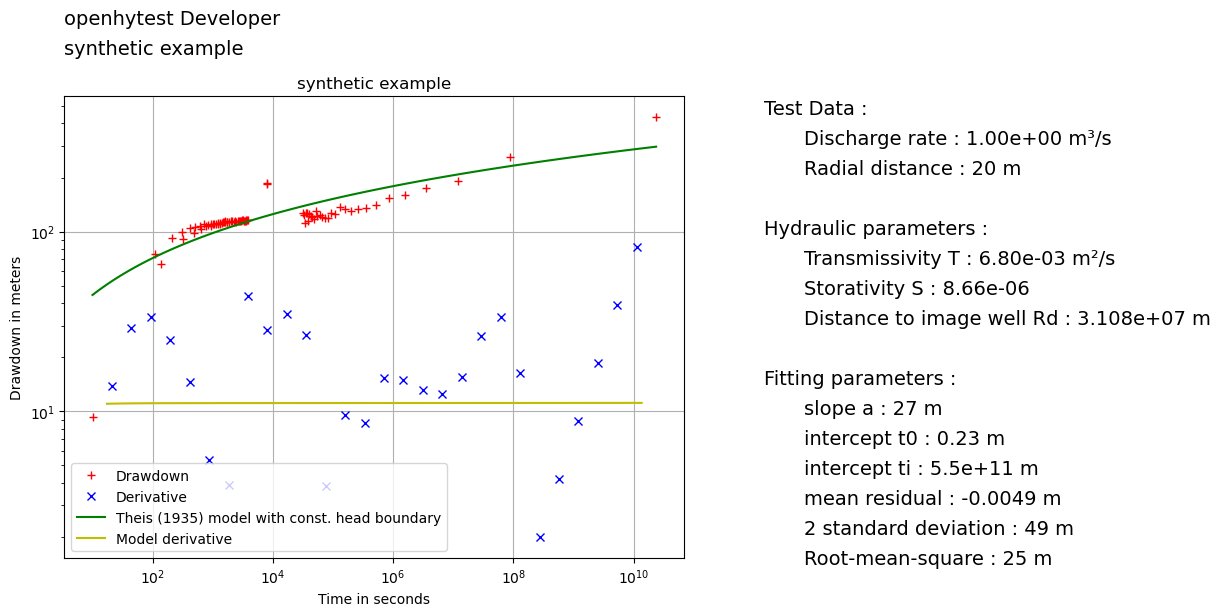

In [5]:
theis_CHB.rpt(fitmethod='trf', ttle='synthetic example', author='openhytest Developer', filetype='pdf', reptext='synthetic_example')

In [6]:
theis_CHB.trial()

T =  0.006800357082621201 m2/s
S =  8.664928441548926e-06 -


## Multirate Theis

The following implementation allow to achieve the same result using the multirate Theis implementation for constant head boundary. The model calculates the drawdown at time t for multiplerate tests without accounting for quadratic head losses after Theis (1935) accounting for constant head boundary. In the end it can also be used to interpret simultaneously the pumping and recovery data.

In [7]:
theis_mrm=ht.Theis_multirate_CHB(r=d, Q=qm, df=data)
theis_mrm.guess_params()
theis_mrm.trial()

`ftol` termination condition is satisfied.
Function evaluations 91, initial cost 6.7644e+05, final cost 2.4034e+04, first-order optimality 4.15e-05.


T =  0.006800357082621201 m2/s
S =  8.664928441548926e-06 -


In [8]:
theis_mrm.fit(fitmethod='trf')
theis_mrm.trial()

`xtol` termination condition is satisfied.
Function evaluations 2, initial cost 1.5374e-01, final cost 9.5192e-02, first-order optimality 4.34e-02.


T =  0.006793999859776353 m2/s
S =  5.7510558879238195e-06 -


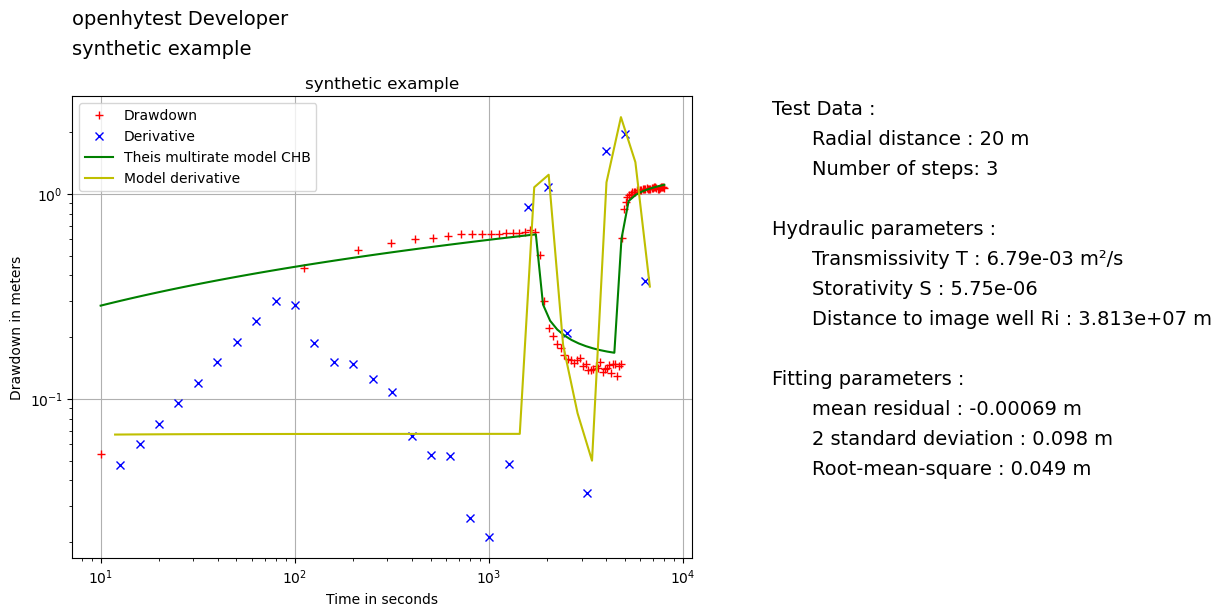

In [9]:
theis_mrm.rpt(fitmethod='nofit', ttle='synthetic example', author='openhytest Developer', filetype='pdf', reptext='synthetic example')